In [1]:
from src.layers.transformer.ATAT import LightCurveTransformer
from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY,ZTF_TAXONOMY

import pandas as pd

In [2]:
colors = [
    '#ffacfa',# agn
    '#D747CF', #qso 1
    "#189a95", # EA 2

    "#bb3e00", #yso 3
    '#70df00',  # snia 4
    "#FE0912", # cvnova 5

    '#009cff',# 6 rrlc  tt
    "#0004ffff",  # 7 rscvn
    "#cd0066",#'#96034A', #blacar 8

    '#2F8B04', # snii 9
    '#7a71f8', # ebew 10
    "#3b3ee7ff", #lpv 11

    "#41708f", # cep 12
    '#00e3ff', # rrlab 13
    '#1FA9FF', # periodic other 14
     '#00e3ff', #dsct 15
    "#458a00", # snibc 16
    "#1E5A2E", # slsn 17
    "#ff8000", # tde 18

    '#FFC71F', # sniib 19
    '#FFEC1F', # sniin 20
    "#FFFFFF", # microlensing 21
    ]

colors_hier = [
    #,'#554FCF
    #'#FBAC23', #agn 0
    '#fd31ee',# agn
    '#fd31ee', #qso 1
    '#00e3ff', # EA 2

    '#fd31ee', #yso 3
    '#1bda00',  # snia 4
    '#fd31ee', # cvnova 5
    '#00e3ff',# 6 rrlc  tt
    '#00e3ff',  # 7 rscvn
    '#fd31ee',#'#96034A', #blacar 8
    '#1bda00', # snii 9
    '#00e3ff', # ebew 10
    '#00e3ff', #lpv 11

    '#00e3ff', # cep 12
    '#00e3ff', # rrlab 13
    '#00e3ff', # periodic other 14
    '#60fff3', #dsct 15
    '#1bda00', # snibc 16
    '#1bda00', # slsn 17
    '#1bda00', # tde 18
    '#1bda00', # sniib 19
    '#1bda00', # sniin 20
    '#1bda00', # microlensing 21
    ]

In [22]:
PATH = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/20260314/LC/20260314/'
FP_DATASET = "/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5"
FP_DATASET ='/home/mdelafuente/ZTF_SSL_Dataset/data/H5_files/BY_PARTITION/200_FF.h5'
#FP_DATASET = "/home/mdelafuente/ORIGINAL/elasticc_dataset_update.h5"


DEVICE = 'cuda:2'
TAXONOMY = ZTF_TAXONOMY

In [37]:
from src.exploringtools.ExplorePretraining import ExplorePretraining
from src.exploringtools.InitDataloader import InitDataLoader



test = ExplorePretraining(path_to_config_yaml=PATH,
                    model= LightCurveTransformer,
                    arg_key='lc')
od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'transformer_tab', 'classifier'],rename_keys = ('model.',''), checkpoint_name='pretrain_ckpt')
test.load_backbone_weights(od)

dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
dl.init_validation_dataset()


Using checkpoint 14878.ckpt
     - Loaded backbone weights


/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/src/exploringtools/InitBackbone.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serializati

In [38]:
X_val, y_val =test.predict(dl.validation_dataset, DEVICE)



device set to cuda:2


  0%|          | 0/382 [00:00<?, ?it/s]

100%|██████████| 382/382 [00:04<00:00, 87.37it/s] 


In [39]:
target = y_val
from sklearn.discriminant_analysis import StandardScaler
import umap
import umap.plot
scaler = StandardScaler()
#bokeh.io.output_notebook(INLINE)
umap_args = {'min_dist':0.1}
umap_obj = umap.UMAP(**umap_args)
#mapper = umap_obj.fit(scaler.fit_transform(X_val))
mapper = umap_obj.fit(X_val)
hover_data = pd.DataFrame({'index':range(len(X_val)),
                            'label':y_val,
                            })

hover_data['class'] = hover_data.label.map({value:key for key,value in TAXONOMY().items()})

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<Axes: >

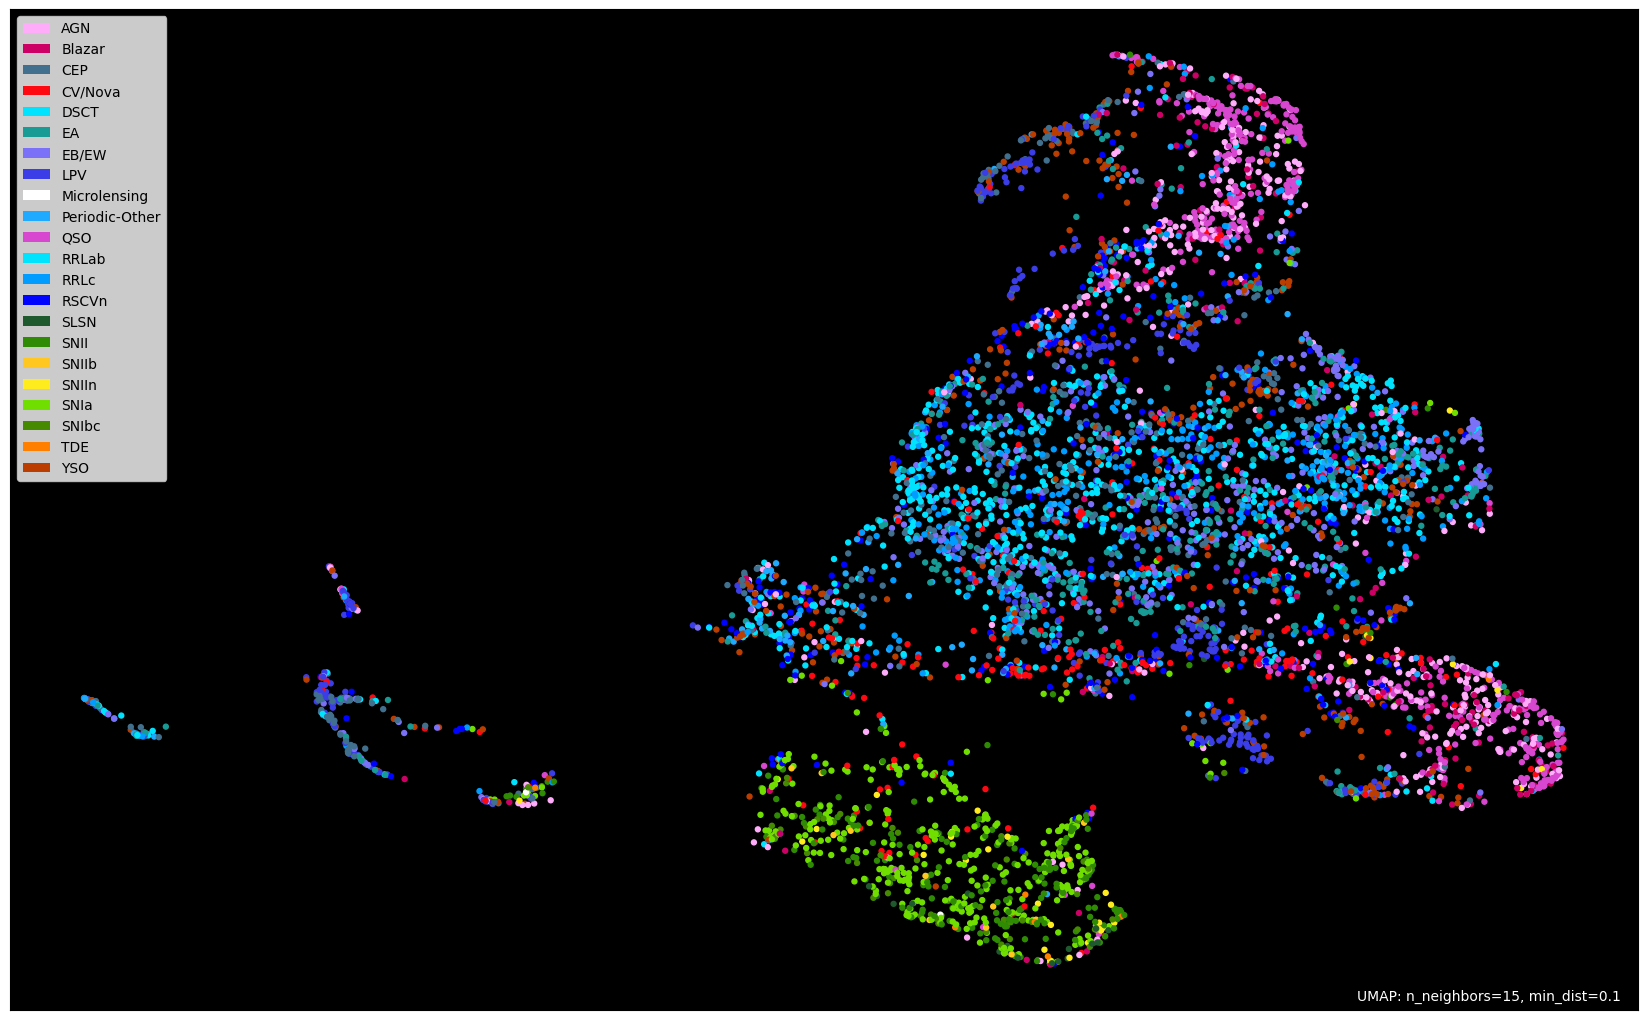

In [40]:
import numpy as np

colors = [
    '#ffacfa',# agn
     "#cd0066",#'#96034A', #blacar 8
      "#41708f", # cep 12
      "#FE0912", # cvnova 5
        '#00e3ff', #dsct 15
    "#189a95", # EA 2
 '#7a71f8', # ebew 10
   "#3b3ee7ff", #lpv 11
     "#FFFFFF", # microlensing 21
      '#1FA9FF', # periodic other 14
       '#D747CF', #qso 1
  '#00e3ff', # rrlab 13
    '#009cff',# 6 rrlc  tt
    "#0004ffff",  # 7 rscvn
      "#1E5A2E", # slsn 17
       '#2F8B04', # snii 9
     '#FFC71F', # sniib 19
    '#FFEC1F', # sniin 20
     '#70df00',  # snia 4
     "#458a00", # snibc 16
       "#ff8000", # tde 18
     "#bb3e00", #yso 3
    ]
import matplotlib.pyplot as plt

fig = plt.figure(figsize = (21,13))
ax = fig.add_subplot(111)
#plt.title('UMAP Dimensionality Reduction Before Pretraining the Embedding Space')
umap.plot.points(mapper, labels = np.array([{value:key for key, value in ZTF_TAXONOMY().items()}[i] for i in target.astype(int)]), height = 1080, width = 1920, background = 'black', color_key = colors, ax = ax)

<Axes: title={'center': 'UMAP Dimensionality Reduction for the Pretrained Embedding Space by Hierarchy Class'}>

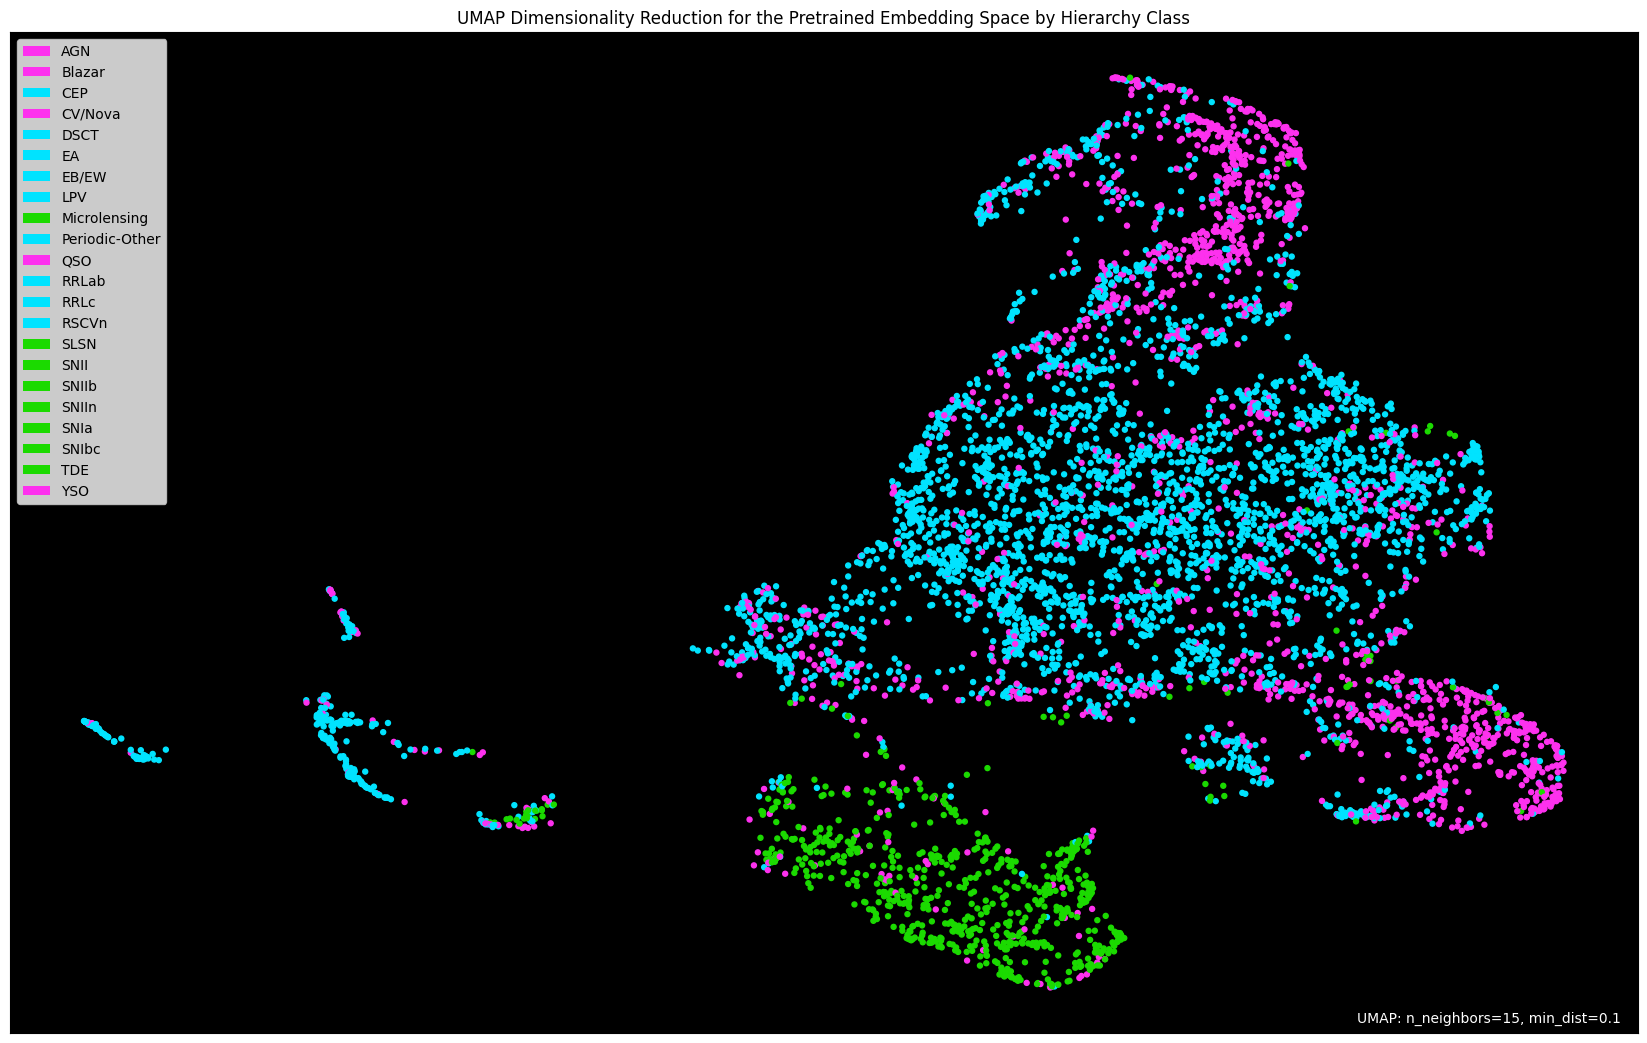

In [41]:

colors_hier = [
    '#fd31ee',# agn
    '#fd31ee', #qso 1

    '#00e3ff', # EA 2

    '#fd31ee', #yso 3

    '#00e3ff', # EA 2
     '#00e3ff',# 6 rrlc
     '#00e3ff',# 6 rrlc
     '#00e3ff',# 6 rrlc
    '#1bda00', # snii 9
    '#00e3ff',# 6 rrlc  tt

    '#fd31ee', # cvnova 5

    '#00e3ff',  # 7 rscvn
    '#00e3ff',  # 7 rscvn
    '#00e3ff',  # 7 rscvn
'#1bda00', # snii 9
'#1bda00', # snii 9
'#1bda00', # snii 9
'#1bda00', # snii 9
'#1bda00', # snii 9
'#1bda00', # snii 9
'#1bda00', # snii 9
 '#fd31ee', # cvnova 5

    ]
fig = plt.figure(figsize = (21,13))
ax = fig.add_subplot(111)
plt.title('UMAP Dimensionality Reduction for the Pretrained Embedding Space by Hierarchy Class')
umap.plot.points(mapper, labels = np.array([{value:key for key, value in ZTF_TAXONOMY().items()}[i] for i in target.astype(int)]), height = 1080, width = 1920, background = 'black', color_key = colors_hier, ax = ax)


In [42]:
colors = [
    '#ffacfa',# agn
    '#D747CF', #qso 1
    "#189a95", # EA 2

    "#bb3e00", #yso 3
    '#70df00',  # snia 4
    "#FE0912", # cvnova 5

    '#009cff',# 6 rrlc  tt
    "#0004ffff",  # 7 rscvn
    "#cd0066",#'#96034A', #blacar 8

    '#2F8B04', # snii 9
    '#7a71f8', # ebew 10
    "#3b3ee7ff", #lpv 11

    "#41708f", # cep 12
    '#00e3ff', # rrlab 13
    '#1FA9FF', # periodic other 14
     '#00e3ff', #dsct 15
    "#458a00", # snibc 16
    "#1E5A2E", # slsn 17
    "#ff8000", # tde 18

    '#FFC71F', # sniib 19
    '#FFEC1F', # sniin 20
    "#FFFFFF", # microlensing 21
    ]
umap.plot.output_notebook()
p = umap.plot.interactive(mapper,
    labels=target,
    hover_data=hover_data,
    point_size=3,
    tools=["pan","wheel_zoom",
    "box_zoom","save",
    "reset","box_select"],
    width=1920,
    height=1080,
    #theme = 'fire',
    #color_key = colors_hier,
    color_key = colors,
    background = 'black', #midnightblue',
    alpha = 0.9)
umap.plot.show(p)

Loading BokehJS ...

In [29]:
#dl.set_sampler(True)
dl.init_train_dataset()
X_train, y_train =test.predict(dl.train_dataset, DEVICE)


device set to cuda:2


  0%|          | 1/1525 [00:00<05:29,  4.63it/s]

100%|██████████| 1525/1525 [00:17<00:00, 86.51it/s]


In [30]:
class_sampler_count  = [1783,1804,1785,1526,1566,1008,1855,1440,872,891,1858,1860,1814,1876,763,973,278,121,56,70,172,17]

weights_dict = {float(i): 1/class_sampler_count[i] for i in range(len(class_sampler_count))}

In [12]:
from sklearn.metrics import classification_report
train_preds, val_preds = test.compute_logistic_regressor(X_train, y_train, X_val, y_val, ZTF_TAXONOMY,weights = weights_dict)

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


                precision    recall  f1-score   support

           AGN     0.3427    0.2483    0.2880       443
           QSO     0.5186    0.5849    0.5498       477
            EA     0.4378    0.1636    0.2382       495
           YSO     0.3894    0.2085    0.2716       422
          SNIa     0.5829    0.3280    0.4198       375
       CV/Nova     0.2471    0.3100    0.2750       271
          RRLc     0.2750    0.2901    0.2824       455
         RSCVn     0.2825    0.1479    0.1942       338
        Blazar     0.1757    0.2476    0.2055       210
          SNII     0.3523    0.1505    0.2109       206
         EB/EW     0.2993    0.4857    0.3704       453
           LPV     0.5612    0.8013    0.6601       458
           CEP     0.3927    0.1670    0.2344       449
         RRLab     0.2123    0.0844    0.1208       450
Periodic-Other     0.2290    0.3030    0.2609       198
          DSCT     0.1554    0.4091    0.2253       242
         SNIbc     0.1325    0.3030    0.1843  

<Axes: title={'center': 'logit reg: validation | macro f1: 0.2488'}, xlabel='Predicted label', ylabel='True label'>

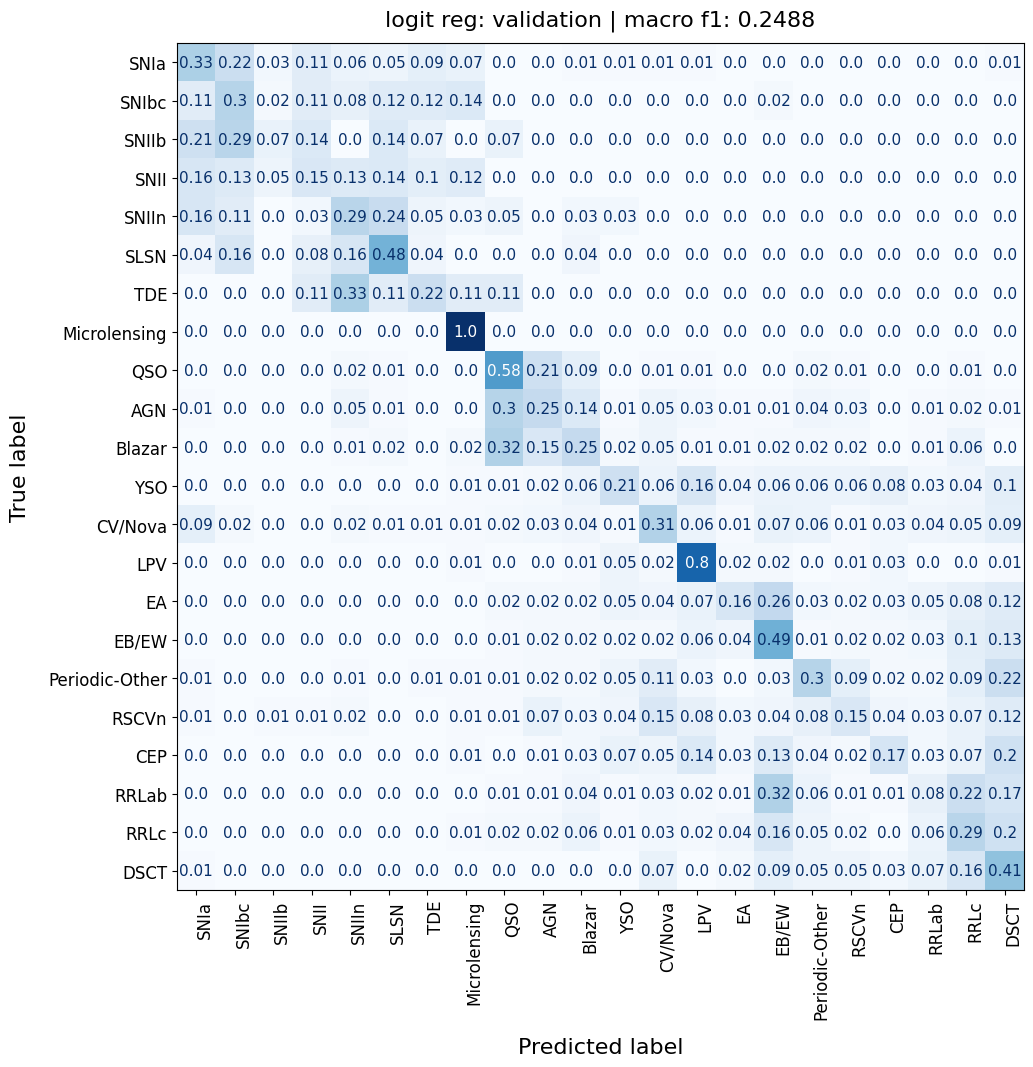

In [13]:
print(classification_report(y_val,val_preds, target_names=list(TAXONOMY().keys()),digits = 4))
test.get_confusion_matrix(val_preds, y_val, ZTF_TAXONOMY, dataset_type = 'validation')

                precision    recall  f1-score   support

           AGN     0.3798    0.3567    0.3679       443
           QSO     0.5269    0.5535    0.5399       477
            EA     0.4644    0.4081    0.4344       495
           YSO     0.3887    0.3436    0.3648       422
          SNIa     0.6059    0.7173    0.6569       375
       CV/Nova     0.3351    0.2399    0.2796       271
          RRLc     0.3143    0.3516    0.3320       455
         RSCVn     0.2927    0.2840    0.2883       338
        Blazar     0.2662    0.1762    0.2120       210
          SNII     0.4851    0.4757    0.4804       206
         EB/EW     0.3945    0.4746    0.4309       453
           LPV     0.7281    0.7424    0.7351       458
           CEP     0.3930    0.4254    0.4086       449
         RRLab     0.3731    0.4378    0.4029       450
Periodic-Other     0.1615    0.1313    0.1448       198
          DSCT     0.1811    0.1818    0.1814       242
         SNIbc     0.2292    0.1667    0.1930  

<Axes: title={'center': 'logit reg: validation | macro f1: 0.3152'}, xlabel='Predicted label', ylabel='True label'>

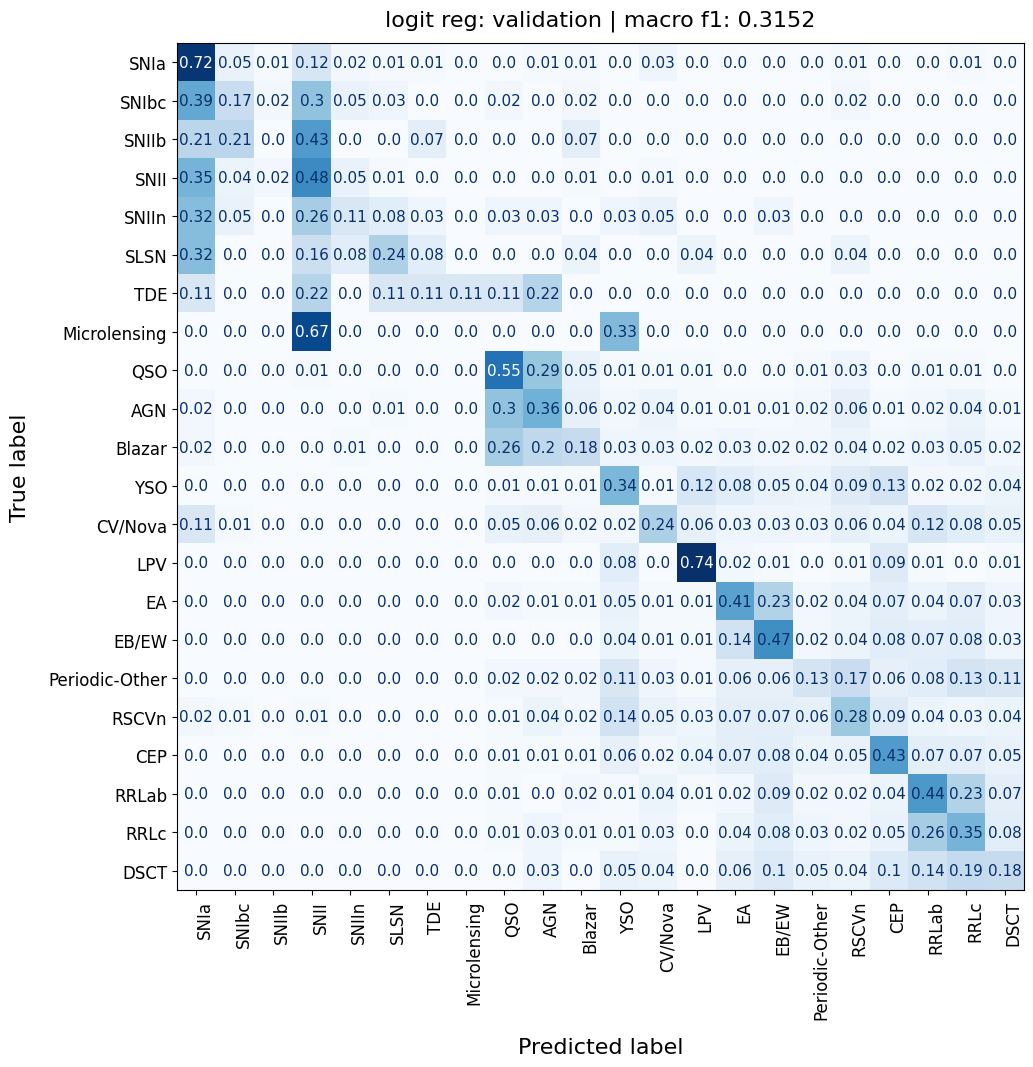

In [14]:
train_preds, val_preds = test.compute_knn(X_train, y_train, X_val, y_val, ZTF_TAXONOMY,model_args = {'n_neighbors': 3,
    'weights':'distance'})

print(classification_report(y_val,val_preds, target_names=list(TAXONOMY().keys()),digits = 4))

test.get_confusion_matrix(val_preds, y_val, ZTF_TAXONOMY, dataset_type = 'validation')